# Réseau résiduel (ResNet) sur CIFAR-10, comparé au CNN de base

Objectif : écrire à la main un ResNet de style ResNet-18 pour CIFAR-10, puis le comparer, **avec exactement la même recette d'entraînement**, à :
- **CNN** : le petit CNN de `CNN.ipynb` (3 couches convolutives, sans BatchNorm) ;
- **PlainNet** : le même réseau que le ResNet, mais **sans connexions résiduelles** ;
- **ResNet** : avec connexions résiduelles.

Comparer PlainNet et ResNet isole l'effet des connexions résiduelles, à profondeur et à nombre de couches identiques. Comparer le CNN et PlainNet montre ce qu'apportent la profondeur et la BatchNorm.

Les données (normalisation, split train / validation de 45 000 / 5 000) sont **identiques à `CNN.ipynb`**.

## 1. Imports, mode DEBUG, device et seeds

- **`DEBUG = True`** : entraînement sur un petit sous-ensemble (5 000 images) pendant 2 epochs. Cela sert à vérifier en quelques minutes que tout le notebook tourne sans erreur. Les résultats n'ont alors **aucune valeur**.
- **`DEBUG = False`** : la vraie expérience, avec 45 000 images et 30 epochs par modèle. Sur GPU, compte de l'ordre d'une heure au total pour les 3 modèles. Sur CPU, c'est beaucoup trop long : reste en DEBUG.

Les seeds rendent l'expérience reproductible. Sur GPU, certaines opérations de cuDNN ne sont pas parfaitement déterministes : deux exécutions peuvent donc différer très légèrement.

In [1]:
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split

DEBUG = False   # True : 5 000 images et 2 epochs, pour tester rapidement que tout fonctionne

NUM_EPOCHS = 2 if DEBUG else 30

# Choix du device : cuda > mps > cpu
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device utilisé :', device)
print('Mode DEBUG :', DEBUG, '| epochs par modèle :', NUM_EPOCHS)

# Seeds pour la reproductibilité (même valeur que dans CNN.ipynb)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);  # le ; évite d'afficher l'objet Generator renvoyé

Device utilisé : cuda
Mode DEBUG : False | epochs par modèle : 30


## 2. Données CIFAR-10 : même split que `CNN.ipynb`, avec augmentation sur le train

- **Normalisation** : même calcul que dans `CNN.ipynb`, avec la moyenne et l'écart-type par canal du jeu d'entraînement.
- **Augmentation**, sur le train uniquement : `RandomCrop(32, padding=4)` (petite translation) et `RandomHorizontalFlip()` (miroir gauche-droite).
- **Validation et test** : sans augmentation.

**Le piège à éviter :** une transformation est attachée à un *dataset*. Si le train et la validation étaient deux sous-ensembles du même dataset, ils auraient forcément la même transformation. On crée donc **deux datasets CIFAR-10** qui contiennent les mêmes 50 000 images :
- `full_train_set_aug` (avec augmentation), dont on prend les **indices du train** ;
- `full_train_set` (sans augmentation), dont on prend les **indices de la validation**.

Les indices viennent du **même appel** à `random_split` que dans `CNN.ipynb` (mêmes tailles, générateur avec la même seed 42). La validation contient donc exactement les mêmes 5 000 images que dans `CNN.ipynb`.

In [2]:
DATA_DIR = './data'
BATCH_SIZE = 128

# Moyenne et écart-type par canal, calculés sur le train comme dans CNN.ipynb
train_raw = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True)
pixels = train_raw.data / 255.0               # (50000, 32, 32, 3), valeurs dans [0, 1]
mean = pixels.mean(axis=(0, 1, 2))            # (3,)
std = pixels.std(axis=(0, 1, 2))              # (3,)
print('Moyenne par canal :', mean)
print('Écart-type par canal :', std)

# Transformations SANS augmentation (validation et test) : identiques à CNN.ipynb
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

# Transformations AVEC augmentation (train uniquement)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),     # ajoute 4 pixels noirs autour puis recadre 32x32 au hasard
    transforms.RandomHorizontalFlip(),        # miroir gauche-droite avec probabilité 0.5
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

# Deux datasets qui contiennent les mêmes 50 000 images, avec des transformations différentes
full_train_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
full_train_set_aug = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

# Même split que CNN.ipynb : même appel, même générateur seedé -> mêmes indices
train_split, val_split = random_split(
    full_train_set, [45000, 5000], generator=torch.Generator().manual_seed(SEED)
)
train_indices = train_split.indices
val_indices = val_split.indices
assert len(set(train_indices) & set(val_indices)) == 0   # aucune image commune entre train et validation

if DEBUG:
    train_indices = train_indices[:5000]   # petit sous-ensemble pour tester vite

train_set = Subset(full_train_set_aug, train_indices)   # train : AVEC augmentation
val_set = Subset(full_train_set, val_indices)           # validation : SANS augmentation

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('Train :', len(train_set), 'images,', len(train_loader), 'batchs (avec augmentation)')
print('Val   :', len(val_set), 'images,', len(val_loader), 'batchs')
print('Test  :', len(test_set), 'images,', len(test_loader), 'batchs')

Moyenne par canal : [0.49139968 0.48215841 0.44653091]
Écart-type par canal : [0.24703223 0.24348513 0.26158784]
Train : 45000 images, 352 batchs (avec augmentation)
Val   : 5000 images, 40 batchs
Test  : 10000 images, 79 batchs


## 3. Le bloc résiduel (BasicBlock)

Un bloc apprend une transformation $F(x)$ à l'aide de deux convolutions 3x3 :

`conv3x3 → BatchNorm → ReLU → conv3x3 → BatchNorm`

- **Avec raccourci** (`use_skip=True`, ResNet) : on calcule $\text{ReLU}(F(x) + x)$. Le bloc n'a qu'à apprendre la **différence** (le résidu) entre sa sortie et son entrée. Si le bloc est inutile, il lui suffit de mettre $F$ proche de 0 pour se comporter comme l'identité. Le gradient peut aussi remonter directement par le raccourci, ce qui facilite l'entraînement des réseaux profonds.
- **Sans raccourci** (`use_skip=False`, PlainNet) : on calcule $\text{ReLU}(F(x))$, un empilement classique de convolutions.

**Quand les dimensions changent** (stride 2 : la taille spatiale est divisée par 2 et le nombre de canaux doublé), $x$ et $F(x)$ n'ont plus la même forme et on ne peut plus les additionner. Le raccourci devient alors une **conv 1x1 avec stride 2, suivie d'une BatchNorm**, qui met $x$ à la bonne forme. Le PlainNet n'a pas de raccourci, donc pas ces convs 1x1, ce qui lui donne un peu moins de paramètres.

Les convolutions n'ont pas de biais (`bias=False`) : la BatchNorm qui les suit a son propre décalage, et un biais serait redondant.

In [3]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        # Exemple de formes pour in=64, out=128, stride=2, avec une entrée (N, 64, 32, 32)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)  # -> (N, 128, 16, 16)
        self.bn1 = nn.BatchNorm2d(out_channels)                                                                  # -> (N, 128, 16, 16)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)     # -> (N, 128, 16, 16)
        self.bn2 = nn.BatchNorm2d(out_channels)                                                                  # -> (N, 128, 16, 16)
        self.relu = nn.ReLU()

        # Raccourci : identité si les formes sont égales, sinon conv 1x1 (avec stride) + BatchNorm
        if use_skip and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),                 # (N, 64, 32, 32) -> (N, 128, 16, 16)
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()   # (inutilisé si use_skip=False)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))   # (N, out, H/stride, W/stride)
        out = self.bn2(self.conv2(out))            # F(x) : (N, out, H/stride, W/stride)
        if self.use_skip:
            out = out + self.shortcut(x)           # F(x) + x : le raccourci a la même forme que F(x)
        return self.relu(out)


# Vérification des formes sur un faux batch
x = torch.zeros(2, 64, 32, 32)
print('stride 1, 64 -> 64  :', tuple(BasicBlock(64, 64)(x).shape))
print('stride 2, 64 -> 128 :', tuple(BasicBlock(64, 128, stride=2)(x).shape))
print('idem sans raccourci :', tuple(BasicBlock(64, 128, stride=2, use_skip=False)(x).shape))

stride 1, 64 -> 64  : (2, 64, 32, 32)
stride 2, 64 -> 128 : (2, 128, 16, 16)
idem sans raccourci : (2, 128, 16, 16)


## 4. Les réseaux : ResNet / PlainNet (style ResNet-18) et le CNN de `CNN.ipynb`

**ResNet de style ResNet-18 pour CIFAR** (les images font 32x32, donc pas de conv 7x7 ni de max-pool au début, contrairement à la version ImageNet) :

| Étape | Contenu | Sortie |
|---|---|---|
| entrée | | (N, 3, 32, 32) |
| stem | conv 3x3, 64 canaux, stride 1 → BN → ReLU | (N, 64, 32, 32) |
| étage 1 | 2 blocs, 64 canaux, stride 1 | (N, 64, 32, 32) |
| étage 2 | 2 blocs, 128 canaux, stride 2 | (N, 128, 16, 16) |
| étage 3 | 2 blocs, 256 canaux, stride 2 | (N, 256, 8, 8) |
| étage 4 | 2 blocs, 512 canaux, stride 2 | (N, 512, 4, 4) |
| pooling | moyenne globale sur H et W | (N, 512) |
| fc | linéaire vers 10 classes | (N, 10) |

On compte 1 + 4×2×2 + 1 = **18 couches** avec poids. Seul le premier bloc de chaque étage peut avoir un stride de 2. L'argument `use_skip` est transmis à tous les blocs : `ResNet(use_skip=False)` donne le **PlainNet**, avec la même architecture, mais sans aucune connexion résiduelle.

**Le CNN** est la classe `SimpleCNN` de `CNN.ipynb`, recopiée telle quelle, sans BatchNorm.

In [4]:
class ResNet(nn.Module):
    def __init__(self, use_skip=True, num_classes=10):
        super().__init__()
                                                                     # entrée : (N, 3, 32, 32)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )                                                            # -> (N, 64, 32, 32)
        self.stage1 = nn.Sequential(BasicBlock(64, 64, stride=1, use_skip=use_skip),
                                    BasicBlock(64, 64, stride=1, use_skip=use_skip))     # -> (N, 64, 32, 32)
        self.stage2 = nn.Sequential(BasicBlock(64, 128, stride=2, use_skip=use_skip),
                                    BasicBlock(128, 128, stride=1, use_skip=use_skip))   # -> (N, 128, 16, 16)
        self.stage3 = nn.Sequential(BasicBlock(128, 256, stride=2, use_skip=use_skip),
                                    BasicBlock(256, 256, stride=1, use_skip=use_skip))   # -> (N, 256, 8, 8)
        self.stage4 = nn.Sequential(BasicBlock(256, 512, stride=2, use_skip=use_skip),
                                    BasicBlock(512, 512, stride=1, use_skip=use_skip))   # -> (N, 512, 4, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)                          # -> (N, 512, 1, 1)  moyenne globale
        self.flatten = nn.Flatten()                                  # -> (N, 512)
        self.fc = nn.Linear(512, num_classes)                        # -> (N, 10)  logits

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.fc(self.flatten(self.pool(x)))


# Classe recopiée telle quelle depuis CNN.ipynb (section 5)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
                                                            # entrée : (N, 3, 32, 32)
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),     # -> (N, 32, 32, 32)
            nn.ReLU(),                                      # -> (N, 32, 32, 32)
            nn.MaxPool2d(2),                                # -> (N, 32, 16, 16)
            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),    # -> (N, 64, 16, 16)
            nn.ReLU(),                                      # -> (N, 64, 16, 16)
            nn.MaxPool2d(2),                                # -> (N, 64, 8, 8)
            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),   # -> (N, 128, 8, 8)
            nn.ReLU(),                                      # -> (N, 128, 8, 8)
            nn.MaxPool2d(2),                                # -> (N, 128, 4, 4)
            # Classifieur
            nn.Flatten(),                                   # -> (N, 128*4*4) = (N, 2048)
            nn.Linear(128 * 4 * 4, 256),                    # -> (N, 256)
            nn.ReLU(),                                      # -> (N, 256)
            nn.Linear(256, num_classes),                    # -> (N, 10)  (logits)
        )

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


# Nombre de paramètres et vérification des formes de sortie
x = torch.zeros(2, 3, 32, 32)
for name, net in [('CNN', SimpleCNN()), ('PlainNet', ResNet(use_skip=False)), ('ResNet', ResNet(use_skip=True))]:
    print(f'{name:8s} : {count_params(net):>10,} paramètres | sortie {tuple(net(x).shape)}')

CNN      :    620,362 paramètres | sortie (2, 10)
PlainNet : 11,000,138 paramètres | sortie (2, 10)
ResNet   : 11,173,962 paramètres | sortie (2, 10)


## 5. Une fonction d'entraînement commune aux trois modèles

`train_one_epoch` et `evaluate` sont celles de `CNN.ipynb`. `train_model` applique la **même recette** à n'importe quel modèle :
- **perte** : `CrossEntropyLoss` ;
- **optimiseur** : SGD avec lr=0.1, momentum=0.9, Nesterov et `weight_decay=5e-4` (régularisation L2 des poids) ;
- **cosine annealing** : le learning rate descend de 0.1 à 0 en suivant une demi-cosinusoïde sur l'ensemble des epochs. On fait de grands pas au début, puis des pas de plus en plus fins. `scheduler.step()` est appelé une fois par epoch ;
- **meilleur modèle** : à chaque nouvelle meilleure val accuracy, les poids sont sauvegardés dans `./checkpoints/<nom>.pt`. Ce dossier est dans le `.gitignore`, donc jamais commité ;
- **test** : **une seule fois, à la toute fin**, après avoir rechargé les poids du meilleur epoch de validation. Le test ne sert jamais à prendre une décision ;
- **même seed** : on refixe la seed au début de `train_model`. Tous les modèles voient donc les batchs dans le même ordre, avec les mêmes tirages d'augmentation.

**Détection de divergence** (utile pour le CNN, voir la section 6a) : si la loss devient `nan` ou infinie, ou si la val accuracy est encore sous 15 % après 3 epochs (alors que le hasard donne 10 %), l'entraînement s'arrête et le résultat est marqué comme divergé. Le test n'est alors pas évalué.

In [5]:
CHECKPOINT_DIR = './checkpoints'


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        scores = model(images)              # (N, 10)
        loss = criterion(scores, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (scores.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()                            # important ici : la BatchNorm utilise ses statistiques globales
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        scores = model(images)
        loss = criterion(scores, labels)

        total_loss += loss.item() * images.size(0)
        correct += (scores.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def train_model(model, name, lr=0.1, num_epochs=NUM_EPOCHS):
    torch.manual_seed(SEED)   # même ordre des batchs et mêmes augmentations pour tous les modèles
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'{name}{"_debug" if DEBUG else ""}.pt')

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': [], 'epoch_time': []}
    best_val_acc, best_epoch, diverged = -1.0, 0, False
    print(f'===== {name} | lr initial = {lr} | {count_params(model):,} paramètres =====')

    start = time.time()
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        current_lr = optimizer.param_groups[0]['lr']   # lr utilisé pendant cette epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()                               # cosine annealing : une mise à jour par epoch
        epoch_time = time.time() - t0

        for key, value in [('train_loss', train_loss), ('train_acc', train_acc), ('val_loss', val_loss),
                           ('val_acc', val_acc), ('lr', current_lr), ('epoch_time', epoch_time)]:
            history[key].append(value)
        print(f'Epoch {epoch:2d}/{num_epochs} | lr {current_lr:.4f} | '
              f'train loss {train_loss:.4f} | train acc {train_acc:.2%} | '
              f'val loss {val_loss:.4f} | val acc {val_acc:.2%} | {epoch_time:.1f} s')

        if val_acc > best_val_acc:                     # nouveau meilleur modèle : on sauvegarde ses poids
            best_val_acc, best_epoch = val_acc, epoch
            torch.save(model.state_dict(), ckpt_path)

        if not math.isfinite(train_loss) or (epoch == 3 and val_acc < 0.15):
            print(f'-> Divergence détectée (train loss {train_loss}, val acc {val_acc:.2%}) : arrêt.')
            diverged = True
            break
    total_time = time.time() - start

    # Test : une seule fois, à la fin, avec les poids du meilleur epoch de validation
    test_acc = None
    if not diverged:
        model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
        _, test_acc = evaluate(model, test_loader, criterion)
        print(f'Meilleure val acc {best_val_acc:.2%} (epoch {best_epoch}) -> test acc {test_acc:.2%} | '
              f'temps total {total_time / 60:.1f} min')

    return {'name': name, 'lr': lr, 'params': count_params(model), 'history': history,
            'best_val_acc': best_val_acc, 'best_epoch': best_epoch, 'test_acc': test_acc,
            'total_time': total_time, 'diverged': diverged}

## 6. Entraînement des trois modèles avec la même recette

Avant chaque modèle, on refixe la seed : les initialisations sont donc reproductibles. Avec la même augmentation, le même optimiseur, le même schedule, le même nombre d'epochs et la même seed, seule l'architecture change.

### 6a. CNN de `CNN.ipynb`

**Attention, exception possible :** le CNN n'a pas de BatchNorm, et lr=0.1 est probablement trop grand pour lui. La loss risque d'exploser (`nan`) ou le réseau de rester bloqué au hasard (10 %). Si c'est le cas, la divergence est détectée et le CNN est **réentraîné avec lr=0.01, uniquement pour lui**. Tout le reste de la recette ne change pas. Le lr effectivement utilisé apparaît dans la sortie et dans le tableau final.

In [6]:
torch.manual_seed(SEED)
cnn = SimpleCNN().to(device)
result_cnn = train_model(cnn, 'CNN', lr=0.1)

if result_cnn['diverged']:
    print()
    print('!' * 80)
    print('lr=0.1 diverge pour le CNN (sans BatchNorm) -> nouvel entraînement avec lr=0.01, UNIQUEMENT pour ce modèle')
    print('!' * 80)
    torch.manual_seed(SEED)
    cnn = SimpleCNN().to(device)   # on repart de poids neufs
    result_cnn = train_model(cnn, 'CNN', lr=0.01)

===== CNN | lr initial = 0.1 | 620,362 paramètres =====
Epoch  1/30 | lr 0.1000 | train loss 1.7800 | train acc 34.61% | val loss 1.4702 | val acc 47.64% | 12.9 s
Epoch  2/30 | lr 0.0997 | train loss 1.7138 | train acc 38.65% | val loss 1.5795 | val acc 41.68% | 13.3 s
Epoch  3/30 | lr 0.0989 | train loss 1.4432 | train acc 48.16% | val loss 1.2210 | val acc 56.38% | 12.7 s
Epoch  4/30 | lr 0.0976 | train loss 1.2897 | train acc 54.30% | val loss 1.2851 | val acc 56.72% | 11.5 s
Epoch  5/30 | lr 0.0957 | train loss 1.2109 | train acc 57.51% | val loss 1.1015 | val acc 61.54% | 11.0 s
Epoch  6/30 | lr 0.0933 | train loss 1.1346 | train acc 60.52% | val loss 1.0841 | val acc 62.56% | 10.8 s
Epoch  7/30 | lr 0.0905 | train loss 1.0926 | train acc 62.07% | val loss 1.0600 | val acc 64.50% | 10.5 s
Epoch  8/30 | lr 0.0872 | train loss 1.0412 | train acc 64.12% | val loss 0.9856 | val acc 67.00% | 10.1 s
Epoch  9/30 | lr 0.0835 | train loss 0.9826 | train acc 66.22% | val loss 0.8868 | val a

### 6b. PlainNet (`ResNet(use_skip=False)`)

Même architecture à 18 couches que le ResNet, avec BatchNorm, mais sans aucune connexion résiduelle.

In [7]:
torch.manual_seed(SEED)
plainnet = ResNet(use_skip=False).to(device)
result_plain = train_model(plainnet, 'PlainNet', lr=0.1)

===== PlainNet | lr initial = 0.1 | 11,000,138 paramètres =====
Epoch  1/30 | lr 0.1000 | train loss 1.8551 | train acc 29.67% | val loss 1.7013 | val acc 36.38% | 43.8 s
Epoch  2/30 | lr 0.0997 | train loss 1.5030 | train acc 44.42% | val loss 1.5608 | val acc 45.50% | 44.0 s
Epoch  3/30 | lr 0.0989 | train loss 1.2653 | train acc 53.86% | val loss 1.3925 | val acc 51.10% | 44.0 s
Epoch  4/30 | lr 0.0976 | train loss 1.0828 | train acc 61.00% | val loss 1.0694 | val acc 61.34% | 43.7 s
Epoch  5/30 | lr 0.0957 | train loss 0.9376 | train acc 66.93% | val loss 0.9306 | val acc 67.72% | 43.6 s
Epoch  6/30 | lr 0.0933 | train loss 0.8267 | train acc 71.11% | val loss 0.9077 | val acc 68.86% | 43.8 s
Epoch  7/30 | lr 0.0905 | train loss 0.7280 | train acc 74.79% | val loss 0.8051 | val acc 71.92% | 43.7 s
Epoch  8/30 | lr 0.0872 | train loss 0.6576 | train acc 77.50% | val loss 0.8357 | val acc 72.72% | 43.8 s
Epoch  9/30 | lr 0.0835 | train loss 0.6113 | train acc 79.11% | val loss 0.6785

### 6c. ResNet (`ResNet(use_skip=True)`)

Le même réseau, cette fois avec les connexions résiduelles.

In [8]:
torch.manual_seed(SEED)
resnet = ResNet(use_skip=True).to(device)
result_resnet = train_model(resnet, 'ResNet', lr=0.1)

===== ResNet | lr initial = 0.1 | 11,173,962 paramètres =====
Epoch  1/30 | lr 0.1000 | train loss 2.2257 | train acc 23.78% | val loss 1.8901 | val acc 31.78% | 47.9 s
Epoch  2/30 | lr 0.0997 | train loss 1.6388 | train acc 38.74% | val loss 1.5614 | val acc 42.32% | 47.9 s
Epoch  3/30 | lr 0.0989 | train loss 1.4199 | train acc 47.61% | val loss 1.3233 | val acc 52.52% | 48.0 s
Epoch  4/30 | lr 0.0976 | train loss 1.1992 | train acc 56.94% | val loss 1.2464 | val acc 56.78% | 47.8 s
Epoch  5/30 | lr 0.0957 | train loss 1.0005 | train acc 64.50% | val loss 0.9962 | val acc 64.82% | 47.8 s
Epoch  6/30 | lr 0.0933 | train loss 0.8590 | train acc 69.71% | val loss 0.9398 | val acc 67.06% | 47.9 s
Epoch  7/30 | lr 0.0905 | train loss 0.7238 | train acc 74.76% | val loss 0.8883 | val acc 69.52% | 47.8 s
Epoch  8/30 | lr 0.0872 | train loss 0.6391 | train acc 77.82% | val loss 0.7181 | val acc 75.22% | 47.8 s
Epoch  9/30 | lr 0.0835 | train loss 0.5737 | train acc 80.04% | val loss 0.7976 |

## 7. Courbes d'apprentissage des trois modèles

Une courbe par modèle sur chaque figure : train loss, val loss et val accuracy en fonction de l'epoch. Regarde à la fois le **niveau final** et la **vitesse** à laquelle chaque courbe descend ou monte dans les premières epochs.

Remarque : la train loss est calculée sur des images augmentées, donc plus difficiles. Elle peut rester au-dessus de la val loss pendant une bonne partie de l'entraînement.

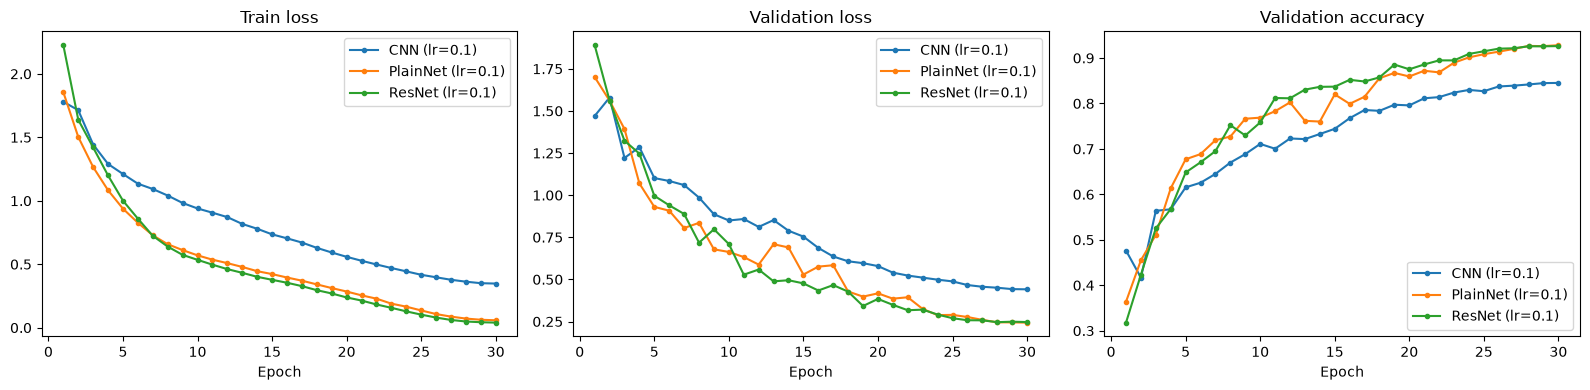

In [9]:
results = [result_cnn, result_plain, result_resnet]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for r in results:
    h = r['history']
    epochs = range(1, len(h['train_loss']) + 1)
    label = f'{r["name"]} (lr={r["lr"]})'
    axes[0].plot(epochs, h['train_loss'], marker='.', label=label)
    axes[1].plot(epochs, h['val_loss'], marker='.', label=label)
    axes[2].plot(epochs, h['val_acc'], marker='.', label=label)

for ax, title in zip(axes, ['Train loss', 'Validation loss', 'Validation accuracy']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Tableau récapitulatif

La dernière ligne rappelle, **pour référence seulement**, le résultat du CNN initial de `CNN.ipynb` (section 9 : 10 epochs, sans augmentation, sans scheduler ni weight decay). Sa recette est différente : on ne peut pas le comparer directement aux trois autres lignes.

In [10]:
CNN_BASELINE_TEST_ACC = 0.7540   # test accuracy obtenue dans CNN.ipynb (section 9)

rows = []
for r in results:
    rows.append({
        'Modèle': r['name'],
        'lr initial': r['lr'],
        'Paramètres': f'{r["params"]:,}',
        'Meilleure val acc': f'{r["best_val_acc"]:.2%} (epoch {r["best_epoch"]})',
        'Test acc': f'{r["test_acc"]:.2%}' if r['test_acc'] is not None else 'non évalué (divergence)',
        'Temps total': f'{r["total_time"] / 60:.1f} min',
        'Remarque': 'lr réduit à 0.01 : lr=0.1 divergeait' if r['lr'] != 0.1 else '',
    })
rows.append({
    'Modèle': 'CNN initial (CNN.ipynb)',
    'lr initial': 0.01,
    'Paramètres': f'{count_params(SimpleCNN()):,}',
    'Meilleure val acc': '-',
    'Test acc': f'{CNN_BASELINE_TEST_ACC:.2%}',
    'Temps total': '-',
    'Remarque': 'recette différente, non comparable (sans augmentation, 10 epochs)',
})

if DEBUG:
    print('ATTENTION : mode DEBUG (5 000 images, 2 epochs), ces chiffres ne sont pas significatifs.')
summary = pd.DataFrame(rows)
summary

,Modèle,lr initial,Paramètres,Meilleure val acc,Test acc,Temps total,Remarque
0,CNN,0.10,"620,362",84.52% (epoch 30),84.57%,5.5 min,
1,PlainNet,0.10,"11,000,138",92.82% (epoch 30),92.08%,21.9 min,
2,ResNet,0.10,"11,173,962",92.62% (epoch 30),92.37%,24.0 min,
3,CNN initial (CNN.ipynb),0.01,"620,362",-,75.40%,-,"recette différente, non comparable (sans augme..."
